# PBI Data Release — Exploration Notebook

This notebook accompanies the **PBI (Phage-Bacteria Interaction) data release** published on Zenodo.  
It serves as a **smoke test** and **introductory guide** for the dataset, demonstrating how to:

1. **Connect to the DuckDB database** and verify the data is intact
2. **Explore phage metadata** with exploratory SQL queries
3. **Inspect the flat CSV files** for phage annotations and host genomes
4. **Understand the manifest** describing every file in the release
5. **Navigate the data-merging reports** (HTML files documenting the ETL process)

## Data Release Structure

```
.
├── duckdb/
│   └── phage_database_optimized.duckdb   ← Star-schema database (all metadata)
├── hosts/                                 ← Host genome metadata (CSV files)
│   ├── assembly_metadata.csv
│   ├── host_download_status.json
│   ├── host_fasta_mapping.json
│   ├── host_metadata.csv
│   ├── phage_host_assemblies.csv
│   ├── phage_host_candidates.csv
│   └── phage_host_links.csv
├── manifest.csv                           ← File inventory with checksums
├── phages/                                ← Phage annotation metadata (CSV files)
│   ├── merged_annotated_proteins_metadata.csv
│   ├── merged_antimicrobial_resistance_gene_metadata.csv
│   ├── merged_crispr_array_metadata.csv
│   ├── merged_phage_anti_crispr_metadata.csv
│   ├── merged_phage_metadata.csv
│   ├── merged_phage_transmembrane_protein_metadata.csv
│   ├── merged_phage_trna_tmrna_metadata.csv
│   ├── merged_phage_virulent_factor_metadata.csv
│   └── merged_transcription_terminator_metadata.csv
└── reports/                               ← HTML data-merging / validation reports
    ├── annotated_proteins_metadata_report.html
    ├── antimicrobial_resistance_gene_metadata_report.html
    ├── crispr_array_metadata_report.html
    ├── database_validation.html
    ├── phage_anti_crispr_metadata_report.html
    ├── phage_metadata_report.html
    ├── phage_transmembrane_protein_metadata_report.html
    ├── phage_trna_tmrna_metadata_report.html
    ├── phage_virulent_factor_metadata_report.html
    └── transcription_terminator_metadata_report.html
```

> **Note:** Large FASTA sequence files are **not** included in this data release to keep the download size manageable.  
> To retrieve nucleotide / protein sequences, use the full PBI pipeline (see the [PBI GitHub repository](https://github.com/ThibaultSchowing/PBI)).

## Requirements

```bash
pip install duckdb pandas matplotlib seaborn
```

## Setup & Path Configuration

Set `DATA_RELEASE_ROOT` to the directory containing the `duckdb/`, `hosts/`, `phages/`, and `reports/` folders.  
When running this notebook **from inside the data release archive**, the default (`Path(".")`) is correct.

In [1]:
import json
import os
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── USER CONFIGURATION ──────────────────────────────────────────────────────
# Set this to the root of the data release (the folder that contains duckdb/,
# hosts/, phages/, reports/, and manifest.csv).
DATA_RELEASE_ROOT = Path(".")
# ────────────────────────────────────────────────────────────────────────────

DB_PATH      = DATA_RELEASE_ROOT / "duckdb" / "phage_database_optimized.duckdb"
PHAGES_DIR   = DATA_RELEASE_ROOT / "phages"
HOSTS_DIR    = DATA_RELEASE_ROOT / "hosts"
REPORTS_DIR  = DATA_RELEASE_ROOT / "reports"
MANIFEST_CSV = DATA_RELEASE_ROOT / "manifest.csv"

# Visualisation defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 20)

print("Data release root:", DATA_RELEASE_ROOT.resolve())
print("DuckDB path      :", DB_PATH)
print("DB file exists   :", DB_PATH.exists())

results_root = Path(os.getenv('PBI_RESULTS_DIR', '/results'))
try:
    results_root.mkdir(parents=True, exist_ok=True)
except Exception:
    results_root = Path.cwd() / 'analysis_results'
    results_root.mkdir(parents=True, exist_ok=True)

NOTEBOOK_RESULTS_DIR = results_root / '04_data_release_exploration'
TABLES_DIR = NOTEBOOK_RESULTS_DIR / 'tables'
FIGURES_DIR = NOTEBOOK_RESULTS_DIR / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook results directory: {NOTEBOOK_RESULTS_DIR}")


Data release root: /mnt/c/Users/TSchowing/Desktop/PBI_stuff/PBIexported/pbi_data_release_v0.2.0
DuckDB path      : duckdb/phage_database_optimized.duckdb
DB file exists   : True


## 1. Manifest — File Inventory

The `manifest.csv` lists every file included in the release together with its size and checksum.  
It is useful for verifying download integrity and understanding what is available.

In [2]:
if MANIFEST_CSV.exists():
    manifest = pd.read_csv(MANIFEST_CSV)
    print(f"Manifest: {len(manifest)} files")
    display(manifest)
else:
    print("manifest.csv not found — skipping.")

Manifest: 28 files


,file,sha256,description
0,duckdb/phage_database_optimized.duckdb,b7b792175f83ebe75e2797db872ed376402b5c5d98b637...,Metadata DuckDB database
1,hosts/assembly_metadata.csv,20db530c8ee19321a29c90b11004298b102546611e7d66...,"Assembly_Accession,Assembly_Name,Organism_Name..."
2,hosts/host_download_status.json,7f5c294f7fcb3853e9e424414ae85b656652fa14dbd291...,"For each raw host from the DuckDB, status if i..."
3,hosts/host_fasta_mapping.json,b9ac9ba94780196a456823a51ef60d899fbf77f522f9ea...,Maps the ID with the path for each host
4,hosts/host_metadata.csv,971283df698b72e2efddd10f08b4bfa6213ce3a01a6f90...,"Host_ID,Species_Name,Strain_Name,Assembly_Acce..."
...,...,...,...
23,reports/phage_metadata_report.html,625e223b384d5913cb89f9a7c5da2e934ce731f2910ec6...,Automatic data summary and visualization of th...
24,reports/phage_transmembrane_protein_metadata_r...,5fdb3990c29c788925c846483fb6eb7d1289f6c1478e7f...,Automatic data summary and visualization of th...
25,reports/phage_trna_tmrna_metadata_report.html,a1844812779f84faf103779fe16e425dd2aed063553922...,Automatic data summary and visualization of th...
26,reports/phage_virulent_factor_metadata_report....,57168f6795d4769d5ada21dc4bbda6b502e5aa91522f80...,Automatic data summary and visualization of th...


## 2. DuckDB Database — Connection & Schema

The DuckDB file at `duckdb/phage_database_optimized.duckdb` is a **star-schema** relational database:

| Table | Description |
|---|---|
| `fact_phages` | Central fact table — one row per phage genome |
| `dim_proteins` | Annotated protein records per phage |
| `dim_terminators` | Predicted transcription terminators |
| `dim_anti_crispr` | Anti-CRISPR protein predictions |
| `dim_virulent_factors` | Virulence factor hits (VFDB) |
| `dim_transmembrane_proteins` | Transmembrane helix predictions (TMHMM) |
| `dim_trna_tmrna` | tRNA / tmRNA predictions |
| `dim_antimicrobial_resistance_genes` | AMR gene hits (RGI / CARD) |
| `dim_crispr_arrays` | CRISPR array predictions |
| `dim_hosts` | Host bacterial species metadata |
| `dim_assembly_metadata` | NCBI assembly-level metadata for host genomes |
| `dim_phage_host_links` | Phage–host infection links |

We open the database in **read-only** mode to avoid write locks.

In [5]:
# Open in read-only mode
conn = duckdb.connect(str(DB_PATH), read_only=True)
print("Connected to DuckDB:", DB_PATH.name)

# List all tables
tables = conn.execute("SHOW TABLES").fetchdf()
print(f"\nTables in database ({len(tables)}):")
for tbl in tables["name"]:
    print(" -", tbl)

Connected to DuckDB: phage_database_optimized.duckdb

Tables in database (24):
 - amr_gene_summary
 - crispr_array_summary
 - crispr_evidence_distribution
 - dim_anti_crispr
 - dim_antimicrobial_resistance_genes
 - dim_assembly_metadata
 - dim_crispr_arrays
 - dim_hosts
 - dim_phage_host_links
 - dim_proteins
 - dim_terminators
 - dim_transmembrane_proteins
 - dim_trna_tmrna
 - dim_virulent_factors
 - fact_phages
 - host_amr_profile
 - host_crispr_profile
 - host_genome_summary
 - phage_complete_profile
 - phage_defense_profile
 - phage_host_associations
 - phage_host_genomes
 - phage_size_distribution
 - phage_summary


### 2.1 Row Counts — Database Overview

A quick row-count query across all tables gives a high-level picture of the dataset size.

> **Performance note:** Row counts are retrieved from DuckDB's internal catalog statistics (`duckdb_tables()`) to avoid full table scans on large tables (e.g. `dim_proteins` with tens of millions of rows).


Querying DuckDB catalog for row count estimates...
Database row counts (estimated from catalog):
                             Table  Row Count
                      dim_proteins   43088582
                   dim_terminators    4640129
        dim_transmembrane_proteins    4020770
                    dim_trna_tmrna    1298181
                       fact_phages     873718
              dim_phage_host_links     782089
                   dim_anti_crispr     299832
                 dim_crispr_arrays      56652
              dim_virulent_factors      23774
             dim_assembly_metadata       5538
                         dim_hosts       5538
dim_antimicrobial_resistance_genes       2602


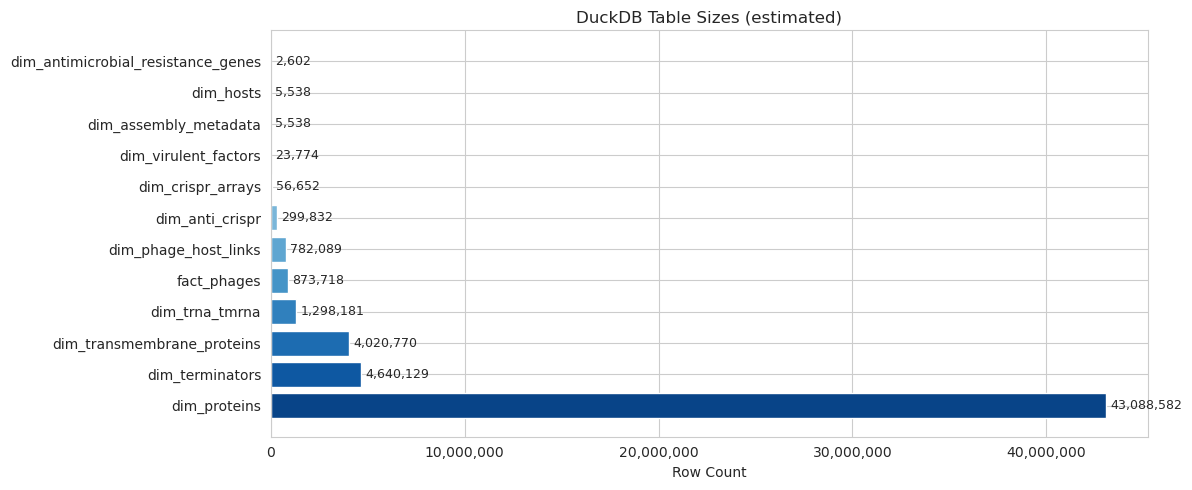

In [4]:
table_names = tables["name"].tolist()

# Use DuckDB's internal catalog for fast row-count estimates.
# This avoids full table scans on large tables (e.g. dim_proteins ~43 M rows).
try:
    print("\nQuerying DuckDB catalog for row count estimates...")
    catalog_df = conn.execute(
        "SELECT table_name, estimated_size FROM duckdb_tables()"
    ).fetchdf()
    row_counts = dict(zip(catalog_df["table_name"], catalog_df["estimated_size"]))
    # Fall back to exact count for any table not covered by the catalog
    #for tbl in table_names:
    #    if tbl not in row_counts:
    #        row_counts[tbl] = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
except Exception:
    # Fallback: exact counts (slow for very large tables)
    print("Catalog query failed — falling back to exact counts (may be slow):")
    row_counts = {}
    for tbl in table_names:
        row_counts[tbl] = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]

counts_df = pd.DataFrame(
    [(tbl, cnt) for tbl, cnt in row_counts.items()],
    columns=["Table", "Row Count"]
).sort_values("Row Count", ascending=False)

print("Database row counts (estimated from catalog):")
print(counts_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(counts_df["Table"], counts_df["Row Count"], color=sns.color_palette("Blues_r", len(counts_df)))
ax.set_xlabel("Row Count")
ax.set_title("DuckDB Table Sizes (estimated)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, counts_df["Row Count"]):
    ax.text(bar.get_width() + max(counts_df["Row Count"]) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Phage Metadata Exploration

The `fact_phages` table is the central table of the database.  
Each row represents one phage genome, annotated with its source database, taxonomy, host, and quality metrics.

In [6]:
# Preview the schema and a few rows
print("Schema of fact_phages:")
display(conn.execute("DESCRIBE fact_phages").fetchdf())

print("\nSample rows:")
display(conn.execute("SELECT * FROM fact_phages LIMIT 5").fetchdf())

Schema of fact_phages:


,column_name,column_type,null,key,default,extra
0,Phage_ID,VARCHAR,YES,None,None,None
1,Source_DB,VARCHAR,YES,None,None,None
2,Length,INTEGER,YES,None,None,None
3,GC_content,DOUBLE,YES,None,None,None
4,Taxonomy,VARCHAR,YES,None,None,None
5,Completeness,VARCHAR,YES,None,None,None
6,Host,VARCHAR,YES,None,None,None
7,Lifestyle,VARCHAR,YES,None,None,None
8,Cluster,VARCHAR,YES,None,None,None
9,Subcluster,VARCHAR,YES,None,None,None



Sample rows:


,Phage_ID,Source_DB,Length,GC_content,Taxonomy,Completeness,Host,Lifestyle,Cluster,Subcluster
0,NC_001330.1,RefSeq,6087,45.178249,Microviridae,High-quality,Escherichia coli,virulent,cluster_158413,subcluster_199459
1,NC_001331.1,RefSeq,7349,61.491359,Inoviridae,Low-quality,Pseudomonas aeruginosa,temperate,cluster_67555,subcluster_85085
2,NC_001332.1,RefSeq,6744,42.719454,Inoviridae,Medium-quality,Escherichia coli,virulent,cluster_63254,subcluster_79716
3,NC_001335.1,RefSeq,52297,62.257873,Caudovirales,High-quality,Mycobacterium smegmatis,temperate,cluster_272329,subcluster_342024
4,NC_001341.1,RefSeq,4491,33.288800,NaN,Not-determined,Acholeplasma laidlawii,virulent,cluster_229441,subcluster_288779


### 3.1 Phage Entries per Source Database

Phages are aggregated from several public databases.  
Understanding the source distribution reveals potential biases and coverage.

Phage entries per source database:


,Source_DB,phage_count,pct
0,GOV2,195699,22.40
1,MGV,189680,21.71
2,IMGVR,177361,20.30
3,GPD,142809,16.34
4,TemPhD,66823,7.65
5,CHVD,44935,5.14
6,GVD,31402,3.59
7,IGVD,10021,1.15
8,RefSeq,4637,0.53
9,STV,4065,0.47


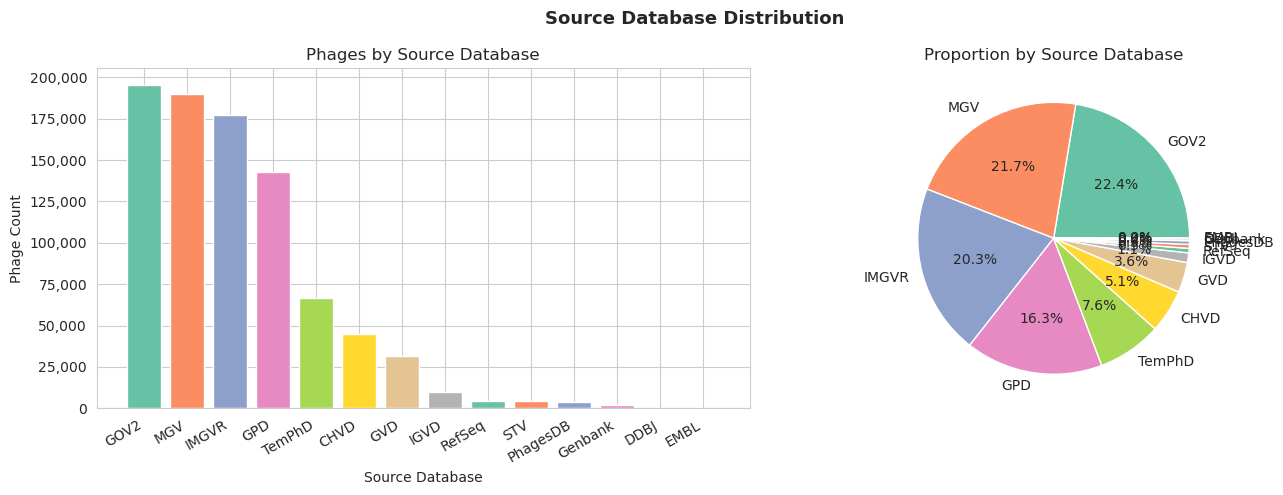

In [7]:
source_df = conn.execute("""
    SELECT
        Source_DB,
        COUNT(*) AS phage_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM fact_phages
    GROUP BY Source_DB
    ORDER BY phage_count DESC
""").fetchdf()

print("Phage entries per source database:")
display(source_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(source_df["Source_DB"], source_df["phage_count"],
            color=sns.color_palette("Set2", len(source_df)))
axes[0].set_xlabel("Source Database")
axes[0].set_ylabel("Phage Count")
axes[0].set_title("Phages by Source Database")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")

# Pie chart
axes[1].pie(source_df["phage_count"], labels=source_df["Source_DB"],
            autopct="%1.1f%%", colors=sns.color_palette("Set2", len(source_df)))
axes[1].set_title("Proportion by Source Database")

plt.suptitle("Source Database Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Genome Length and GC Content

Genome length (bp) and GC content (%) are fundamental quality metrics for phage genomes.

> **Performance note:** Histograms are drawn from a random reservoir sample of up to 50 000 rows so that plotting remains fast even for large tables.

Genome length and GC content summary:


,Value
total_phages,873718.00
with_length,873718.00
min_length,203.00
max_length,553716.00
avg_length,37564.00
median_length,33982.00
with_gc,873718.00
min_gc,17.92
max_gc,78.50
avg_gc,44.19


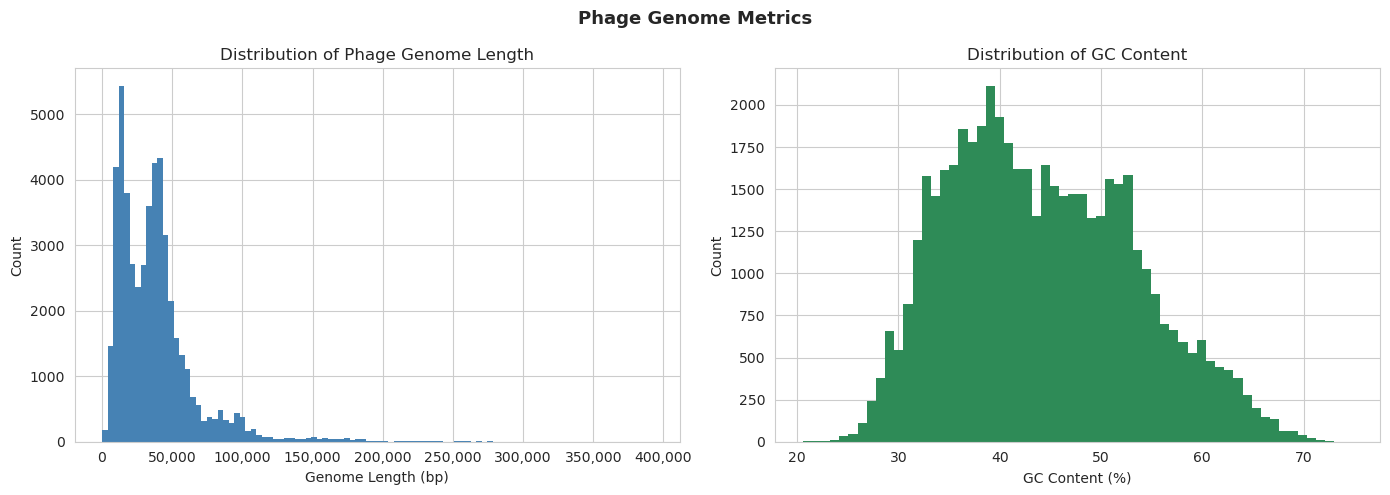

In [8]:
genome_stats = conn.execute("""
    SELECT
        COUNT(*)                          AS total_phages,
        COUNT(Length)                     AS with_length,
        MIN(Length)                       AS min_length,
        MAX(Length)                       AS max_length,
        ROUND(AVG(Length), 0)             AS avg_length,
        ROUND(MEDIAN(Length), 0)          AS median_length,
        COUNT(GC_content)                 AS with_gc,
        ROUND(MIN(GC_content), 2)         AS min_gc,
        ROUND(MAX(GC_content), 2)         AS max_gc,
        ROUND(AVG(GC_content), 2)         AS avg_gc
    FROM fact_phages
""").fetchdf()

print("Genome length and GC content summary:")
display(genome_stats.T.rename(columns={0: "Value"}))

# Sample up to 50 000 rows for histograms (avoids fetching millions of rows)
length_gc = conn.execute("""
    SELECT Length, GC_content
    FROM fact_phages
    WHERE Length IS NOT NULL AND GC_content IS NOT NULL
    USING SAMPLE reservoir(50000 ROWS)
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(length_gc["Length"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Genome Length (bp)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Phage Genome Length")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(length_gc["GC_content"], bins=60, color="seagreen", edgecolor="none")
axes[1].set_xlabel("GC Content (%)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of GC Content")

plt.suptitle("Phage Genome Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Lifestyle Distribution

Phages are classified as **lytic** (virulent — lyse the host) or **temperate** (lysogenic — integrate into the host genome).  
A large fraction may be unlabelled (`NULL` or unknown).

,Lifestyle,count
0,virulent,553688
1,temperate,320030


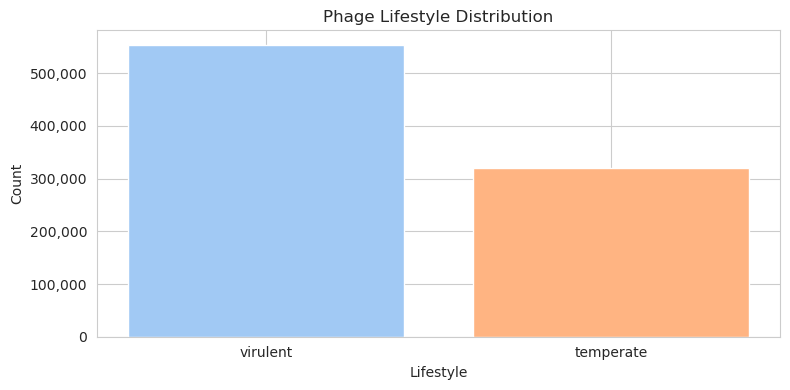

In [9]:
lifestyle_df = conn.execute("""
    SELECT
        COALESCE(Lifestyle, 'Unknown') AS Lifestyle,
        COUNT(*)                        AS count
    FROM fact_phages
    GROUP BY Lifestyle
    ORDER BY count DESC
""").fetchdf()

display(lifestyle_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lifestyle_df["Lifestyle"], lifestyle_df["count"],
       color=sns.color_palette("pastel", len(lifestyle_df)))
ax.set_xlabel("Lifestyle")
ax.set_ylabel("Count")
ax.set_title("Phage Lifestyle Distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 3.4 Genome Completeness

Completeness is predicted by CheckV (for metagenomic contigs) or taken from source database annotations.

,Completeness,count
0,High-quality,300137
1,Low-quality,267050
2,Medium-quality,212175
3,Complete,72668
4,Not-determined,21688


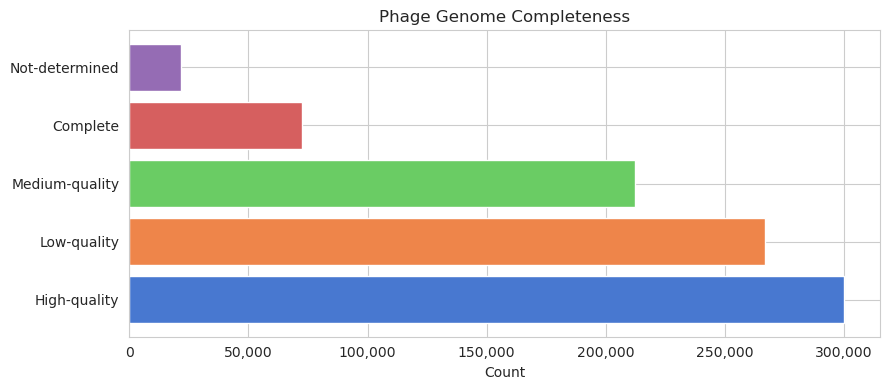

In [10]:
completeness_df = conn.execute("""
    SELECT
        COALESCE(Completeness, 'Unknown') AS Completeness,
        COUNT(*) AS count
    FROM fact_phages
    GROUP BY Completeness
    ORDER BY count DESC
""").fetchdf()

display(completeness_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(completeness_df["Completeness"], completeness_df["count"],
        color=sns.color_palette("muted", len(completeness_df)))
ax.set_xlabel("Count")
ax.set_title("Phage Genome Completeness")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 3.5 Top Phage Hosts

The `Host` column records the bacterial genus/species reported as host in the source database.

,Host,phage_count
0,Salmonella enterica,47897
1,Lawsonia intracellularis,38339
2,Clostridioides difficile,29435
3,Lachnospiraceae,27751
4,Bacteroides,22341
5,Bacteroidaceae,21818
6,Escherichia coli,20669
7,Bacillus cereus,19813
8,Faecalibacterium,17851
9,Streptococcus agalactiae,16038


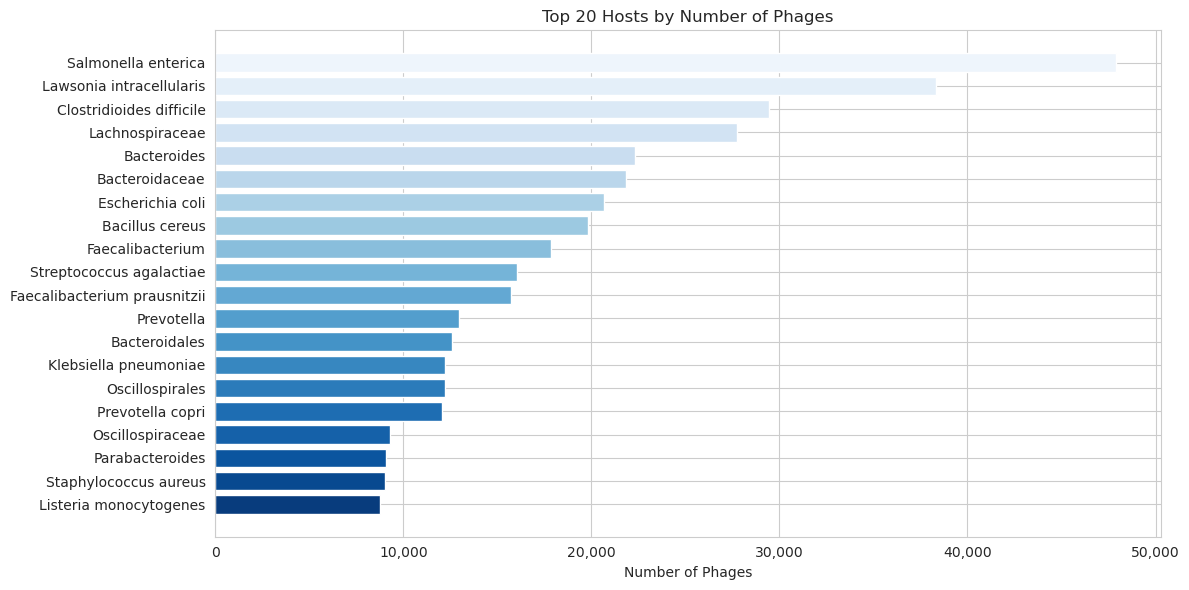

In [11]:
top_hosts = conn.execute("""
    SELECT
        Host,
        COUNT(*) AS phage_count
    FROM fact_phages
    WHERE Host IS NOT NULL AND Host != '-'
    GROUP BY Host
    ORDER BY phage_count DESC
    LIMIT 20
""").fetchdf()

display(top_hosts)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_hosts["Host"][::-1], top_hosts["phage_count"][::-1],
        color=sns.color_palette("Blues", len(top_hosts))[::-1])
ax.set_xlabel("Number of Phages")
ax.set_title("Top 20 Hosts by Number of Phages")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 3.6 Phage–Host Links

The `dim_phage_host_links` table records verified phage–host infection pairs used for downstream machine-learning tasks.

In [13]:
if "dim_phage_host_links" in table_names:
    print("Schema of dim_phage_host_links:")
    display(conn.execute("DESCRIBE dim_phage_host_links").fetchdf())

    link_stats = conn.execute("""
        SELECT
            COUNT(*)                    AS total_links,
            COUNT(DISTINCT Phage_ID)    AS unique_phages,
            COUNT(DISTINCT Assembly_Accession) AS unique_host_assemblies
        FROM dim_phage_host_links
    """).fetchdf()
    print("\nPhage–host link statistics:")
    display(link_stats)

    print("\nSample rows:")
    display(conn.execute("SELECT * FROM dim_phage_host_links LIMIT 10").fetchdf())
else:
    print("dim_phage_host_links table not found in this database.")

Schema of dim_phage_host_links:


,column_name,column_type,null,key,default,extra
0,Phage_ID,VARCHAR,YES,None,None,None
1,Host_Species,VARCHAR,YES,None,None,None
2,Host_Full_Name,VARCHAR,YES,None,None,None
3,Assembly_Accession,VARCHAR,YES,None,None,None
4,Assembly_Level,VARCHAR,YES,None,None,None
5,RefSeq_Category,VARCHAR,YES,None,None,None
6,Link_Quality,VARCHAR,YES,None,None,None



Phage–host link statistics:


,total_links,unique_phages,unique_host_assemblies
0,782089,771006,5538



Sample rows:


,Phage_ID,Host_Species,Host_Full_Name,Assembly_Accession,Assembly_Level,RefSeq_Category,Link_Quality
0,6982.1.58137.GGACC_Malaspina_NODE_113_length_3...,Lawsonia intracellularis,Lawsonia intracellularis,GCF_025736895.1,Complete Genome,na,direct
1,6982.1.58137.GGACC_Malaspina_NODE_215_length_2...,Mycobacteroides abscessus,Mycobacteroides abscessus,GCF_054926105.1,Complete Genome,na,direct
2,6982.1.58137.GGACC_Malaspina_NODE_229_length_2...,Pseudomonas syringae,Pseudomonas syringae,GCF_054132535.1,Complete Genome,na,direct
3,6982.1.58137.GGACC_Malaspina_NODE_267_length_2...,Lawsonia intracellularis,Lawsonia intracellularis,GCF_025736895.1,Complete Genome,na,direct
4,6982.1.58137.GGACC_Malaspina_NODE_486_length_1...,Enterobacter cloacae,Enterobacter cloacae,GCF_051046885.1,Complete Genome,na,direct
5,6982.1.58137.GGACC_Malaspina_NODE_507_length_1...,Pseudomonas aeruginosa,Pseudomonas aeruginosa,GCF_054903515.1,Complete Genome,na,direct
6,6982.1.58137.GGACC_Malaspina_NODE_510_length_1...,Serratia marcescens,Serratia marcescens,GCF_052836085.1,Complete Genome,na,direct
7,6982.1.58137.GGACC_Malaspina_NODE_512_length_1...,Pseudomonas fluorescens,Pseudomonas fluorescens,GCF_977010515.1,Complete Genome,na,direct
8,6982.1.58137.GGACC_Malaspina_NODE_528_length_1...,Enterobacter hormaechei,Enterobacter hormaechei,GCF_054898265.1,Complete Genome,na,direct
9,6982.1.58137.GGACC_Malaspina_NODE_539_length_1...,Bacillus safensis,Bacillus safensis,GCF_051425535.1,Complete Genome,na,direct


## 4. Phage Annotation Files (`phages/` directory)

The `phages/` directory contains flat CSV files — one per annotation type — produced by merging data from all source databases.  
These files are also loaded into the DuckDB dimension tables above.

| File | DuckDB table | Description |
|---|---|---|
| `merged_phage_metadata.csv` | `fact_phages` | Core phage genome metadata |
| `merged_annotated_proteins_metadata.csv` | `dim_proteins` | Protein annotations (function, physicochemical properties) |
| `merged_transcription_terminator_metadata.csv` | `dim_terminators` | Rho-independent terminators (TransTermHP) |
| `merged_phage_anti_crispr_metadata.csv` | `dim_anti_crispr` | Anti-CRISPR protein predictions |
| `merged_phage_virulent_factor_metadata.csv` | `dim_virulent_factors` | Virulence factor hits (VFDB) |
| `merged_phage_transmembrane_protein_metadata.csv` | `dim_transmembrane_proteins` | Transmembrane topology (TMHMM) |
| `merged_phage_trna_tmrna_metadata.csv` | `dim_trna_tmrna` | tRNA / tmRNA predictions (ARAGORN) |
| `merged_antimicrobial_resistance_gene_metadata.csv` | `dim_antimicrobial_resistance_genes` | AMR gene hits (RGI / CARD) |
| `merged_crispr_array_metadata.csv` | `dim_crispr_arrays` | CRISPR array predictions (CRISPRCasFinder) |

In [14]:
phage_csvs = sorted(PHAGES_DIR.glob("*.csv"))
print(f"Files in phages/ ({len(phage_csvs)}):")

phage_file_stats = []
for csv_path in phage_csvs:
    try:
        df = pd.read_csv(csv_path, nrows=0)  # load only header
        # Count rows via DuckDB (faster than Python line iteration for large files)
        try:
            row_count = conn.execute(
                f"SELECT COUNT(*) FROM read_csv_auto('{csv_path}', header=true)"
            ).fetchone()[0]
        except Exception:
            with open(csv_path, "rb") as f:
                row_count = sum(1 for _ in f) - 1  # subtract header
        phage_file_stats.append({
            "File": csv_path.name,
            "Rows": row_count,
            "Columns": len(df.columns),
            "Size (MB)": round(csv_path.stat().st_size / 1024**2, 2)
        })
    except Exception as e:
        phage_file_stats.append({"File": csv_path.name, "Rows": "error",
                                  "Columns": "error", "Size (MB)": "error"})

phage_files_df = pd.DataFrame(phage_file_stats)
display(phage_files_df)

Files in phages/ (9):


,File,Rows,Columns,Size (MB)
0,merged_annotated_proteins_metadata.csv,43088582,20,12227.27
1,merged_antimicrobial_resistance_gene_metadata.csv,2602,7,0.30
2,merged_crispr_array_metadata.csv,56652,26,14.22
3,merged_phage_anti_crispr_metadata.csv,299832,5,22.66
4,merged_phage_metadata.csv,873718,10,142.96
5,merged_phage_transmembrane_protein_metadata.csv,4020770,18,723.77
6,merged_phage_trna_tmrna_metadata.csv,1298181,12,292.71
7,merged_phage_virulent_factor_metadata.csv,23774,5,2.12
8,merged_transcription_terminator_metadata.csv,4640129,8,304.14


### 4.1 Preview: Core Phage Metadata CSV

In [15]:
phage_meta_csv = PHAGES_DIR / "merged_phage_metadata.csv"
if phage_meta_csv.exists():
    phage_meta = pd.read_csv(phage_meta_csv, nrows=5)
    print(f"Columns ({len(phage_meta.columns)}): {list(phage_meta.columns)}")
    display(phage_meta)
else:
    print(f"{phage_meta_csv} not found.")

Columns (10): ['Phage_ID', 'Length', 'GC_content', 'Taxonomy', 'Completeness', 'Host', 'Lifestyle', 'Cluster', 'Subcluster', 'Source_DB']


,Phage_ID,Length,GC_content,Taxonomy,Completeness,Host,Lifestyle,Cluster,Subcluster,Source_DB
0,NC_001330.1,6087.0,45.178249,Microviridae,High-quality,Escherichia coli,virulent,cluster_158413,subcluster_199459,RefSeq
1,NC_001331.1,7349.0,61.491359,Inoviridae,Low-quality,Pseudomonas aeruginosa,temperate,cluster_67555,subcluster_85085,RefSeq
2,NC_001332.1,6744.0,42.719454,Inoviridae,Medium-quality,Escherichia coli,virulent,cluster_63254,subcluster_79716,RefSeq
3,NC_001335.1,52297.0,62.257873,Caudovirales,High-quality,Mycobacterium smegmatis,temperate,cluster_272329,subcluster_342024,RefSeq
4,NC_001341.1,4491.0,33.288800,NaN,Not-determined,Acholeplasma laidlawii,virulent,cluster_229441,subcluster_288779,RefSeq


### 4.2 Preview: Annotated Proteins

In [16]:
proteins_csv = PHAGES_DIR / "merged_annotated_proteins_metadata.csv"
if proteins_csv.exists():
    proteins_df = pd.read_csv(proteins_csv, nrows=5)
    print(f"Columns ({len(proteins_df.columns)}): {list(proteins_df.columns)}")
    display(proteins_df)
else:
    print(f"{proteins_csv} not found.")

Columns (20): ['Phage_ID', 'Protein_source', 'Function_prediction_source', 'Start', 'Stop', 'Strand', 'Protein_ID', 'Product', 'Protein_classification', 'Molecular_weight', 'Aromaticity', 'Instability_index', 'Isoelectric_point', 'Helix_fraction', 'Turn_fraction', 'Sheet_fraction', 'Reduced_coefficient', 'Oxidized_coefficient', 'Source_DB', 'Phage_Source']


,Phage_ID,Protein_source,Function_prediction_source,Start,Stop,Strand,Protein_ID,Product,Protein_classification,Molecular_weight,Aromaticity,Instability_index,Isoelectric_point,Helix_fraction,Turn_fraction,Sheet_fraction,Reduced_coefficient,Oxidized_coefficient,Source_DB,Phage_Source
0,NC_001330.1,RefSeq,RefSeq,759.0,2243.0,+,NP_039590.1,replication initiation protein,replication;,407.4640,0.250000,17.125000,8.750052,0.250000,0.500000,0.000000,0.0,0.0,RefSeq,RefSeq
1,NC_001330.1,RefSeq,RefSeq,1805.0,2158.0,+,NP_039591.1,internal scaffolding protein,assembly;,5650.1306,0.234043,17.321489,7.018615,0.297872,0.212766,0.170213,9970.0,9970.0,RefSeq,RefSeq
2,NC_001330.1,RefSeq,RefSeq,2158.0,2319.0,+,NP_039592.1,hypothetical protein,hypothetical;,6235.2870,0.037736,37.058491,6.816041,0.339623,0.132075,0.377358,0.0,125.0,RefSeq,RefSeq
3,NC_001330.1,RefSeq,RefSeq,2270.0,2476.0,+,NP_039593.1,DNA maturation protein,infection;,8295.3801,0.161765,32.102941,9.300419,0.338235,0.132353,0.279412,22460.0,22460.0,RefSeq,RefSeq
4,NC_001330.1,RefSeq,RefSeq,2503.0,2955.0,+,NP_039594.1,external scaffolding protein,assembly;,1183.4075,0.000000,15.510000,11.999968,0.200000,0.200000,0.300000,0.0,0.0,RefSeq,RefSeq


### 4.3 Annotation Coverage per Phage

Not every phage has entries in every annotation table.  
This query shows what fraction of phages have at least one record in each dimension table.

,Annotation,Phages with annotation,Coverage (%)
0,Annotated proteins,871350,99.7
4,Transmembrane proteins,764162,87.5
1,Transcription terminators,582941,66.7
5,tRNA / tmRNA,241902,27.7
2,Anti-CRISPR proteins,124366,14.2
7,CRISPR arrays,49468,5.7
3,Virulence factors,11108,1.3
6,AMR genes,2120,0.2


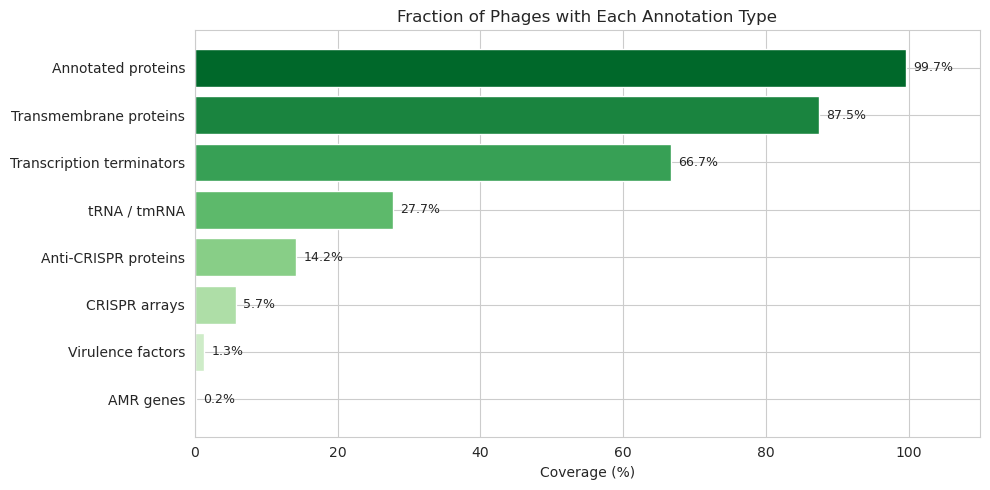

In [17]:
total_phages = conn.execute("SELECT COUNT(*) FROM fact_phages").fetchone()[0]

annotation_tables = [
    ("dim_proteins",                        "Annotated proteins"),
    ("dim_terminators",                     "Transcription terminators"),
    ("dim_anti_crispr",                     "Anti-CRISPR proteins"),
    ("dim_virulent_factors",                "Virulence factors"),
    ("dim_transmembrane_proteins",          "Transmembrane proteins"),
    ("dim_trna_tmrna",                      "tRNA / tmRNA"),
    ("dim_antimicrobial_resistance_genes",  "AMR genes"),
    ("dim_crispr_arrays",                   "CRISPR arrays"),
]

coverage_rows = []
for tbl, label in annotation_tables:
    if tbl in table_names:
        # Use an estimate for very large tables to avoid slow COUNT(DISTINCT) scans
        tbl_rows = row_counts.get(tbl, 0)
        if tbl_rows > 5_000_000:
            # Approximate via 10 % sample (fast, representative)
            phages_annotated = conn.execute(
                f"SELECT COUNT(DISTINCT Phage_ID) FROM {tbl} USING SAMPLE 10 PERCENT"
            ).fetchone()[0]
            phages_annotated = int(phages_annotated * 10)  # scale back up
        else:
            phages_annotated = conn.execute(
                f"SELECT COUNT(DISTINCT Phage_ID) FROM {tbl}"
            ).fetchone()[0]
        coverage_rows.append({
            "Annotation": label,
            "Phages with annotation": phages_annotated,
            "Coverage (%)": round(phages_annotated / total_phages * 100, 1)
        })

coverage_df = pd.DataFrame(coverage_rows).sort_values("Coverage (%)", ascending=False)
display(coverage_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coverage_df["Annotation"][::-1], coverage_df["Coverage (%)"][::-1],
        color=sns.color_palette("Greens", len(coverage_df)))
ax.set_xlabel("Coverage (%)")
ax.set_title("Fraction of Phages with Each Annotation Type")
ax.set_xlim(0, 110)
for i, (val, label) in enumerate(zip(coverage_df["Coverage (%)"][::-1], coverage_df["Annotation"][::-1])):
    ax.text(val + 1, i, f"{val}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Host Files (`hosts/` directory)

The `hosts/` directory contains metadata about the **bacterial host genomes** used for phage–host interaction analysis.

| File | Description |
|---|---|
| `host_metadata.csv` | Species-level host metadata (taxonomy, source DB) |
| `assembly_metadata.csv` | NCBI assembly metadata for downloaded host genomes |
| `phage_host_links.csv` | Phage–host infection links (IDs only) |
| `phage_host_assemblies.csv` | Phage–host pairs with assembly-level detail |
| `phage_host_candidates.csv` | Candidate host–phage pairs before filtering |
| `host_download_status.json` | Download status for each host genome |
| `host_fasta_mapping.json` | Mapping of host IDs to local FASTA file paths |

In [18]:
host_csvs = sorted(HOSTS_DIR.glob("*.csv"))
host_jsons = sorted(HOSTS_DIR.glob("*.json"))

print(f"CSV files in hosts/ ({len(host_csvs)}):")
host_file_stats = []
for csv_path in host_csvs:
    try:
        df = pd.read_csv(csv_path, nrows=0)
        # Count rows via DuckDB (faster than Python line iteration for large files)
        try:
            row_count = conn.execute(
                f"SELECT COUNT(*) FROM read_csv_auto('{csv_path}', header=true)"
            ).fetchone()[0]
        except Exception:
            with open(csv_path, "rb") as f:
                row_count = sum(1 for _ in f) - 1
        host_file_stats.append({
            "File": csv_path.name,
            "Rows": row_count,
            "Columns": len(df.columns),
            "Size (MB)": round(csv_path.stat().st_size / 1024**2, 2)
        })
    except Exception as e:
        host_file_stats.append({"File": csv_path.name, "Rows": "error",
                                 "Columns": "error", "Size (MB)": "error"})

display(pd.DataFrame(host_file_stats))

print(f"\nJSON files in hosts/ ({len(host_jsons)}):")
for j in host_jsons:
    size_kb = j.stat().st_size / 1024
    print(f"  {j.name:40s}  {size_kb:.1f} KB")

CSV files in hosts/ (5):


,File,Rows,Columns,Size (MB)
0,assembly_metadata.csv,5538,17,1.28
1,host_metadata.csv,5538,11,0.72
2,phage_host_assemblies.csv,782089,14,123.48
3,phage_host_candidates.csv,879615,5,76.34
4,phage_host_links.csv,782089,7,92.29



JSON files in hosts/ (2):
  host_download_status.json                 324.5 KB
  host_fasta_mapping.json                   404.7 KB


### 5.1 Host Metadata

In [19]:
host_meta_csv = HOSTS_DIR / "host_metadata.csv"
if host_meta_csv.exists():
    host_meta = pd.read_csv(host_meta_csv, nrows=1000)
    print(f"Host metadata: {len(host_meta):,} rows loaded (limited to 1 000 for preview), ")
    print(f"Columns ({len(host_meta.columns)}): {list(host_meta.columns)}")
    display(host_meta.head())
else:
    print(f"{host_meta_csv} not found.")

Host metadata: 1,000 rows loaded (limited to 1 000 for preview), 
Columns (11): ['Host_ID', 'Species_Name', 'Strain_Name', 'Assembly_Accession', 'Assembly_Name', 'Assembly_Level', 'Genome_Length', 'GC_Content', 'RefSeq_Category', 'Download_Date', 'Source']


,Host_ID,Species_Name,Strain_Name,Assembly_Accession,Assembly_Name,Assembly_Level,Genome_Length,GC_Content,RefSeq_Category,Download_Date,Source
0,GCF_025736895_1,Lawsonia intracellularis,-,GCF_025736895.1,ASM2573689v1,Complete Genome,1699035,32.94,na,2026-02-19,assembly_resolver
1,GCF_054926105_1,Mycobacteroides abscessus,-,GCF_054926105.1,ASM5492610v1,Complete Genome,4989215,64.23,na,2026-02-19,assembly_resolver
2,GCF_054132535_1,Pseudomonas syringae,-,GCF_054132535.1,ASM5413253v1,Complete Genome,6012225,59.02,na,2026-02-19,assembly_resolver
3,GCF_051046885_1,Enterobacter cloacae,-,GCF_051046885.1,ASM5104688v1,Complete Genome,4935288,54.92,na,2026-02-19,assembly_resolver
4,GCF_054903515_1,Pseudomonas aeruginosa,-,GCF_054903515.1,ASM5490351v1,Complete Genome,6417544,66.41,na,2026-02-19,assembly_resolver


### 5.2 Assembly Metadata

In [20]:
assembly_csv = HOSTS_DIR / "assembly_metadata.csv"
if assembly_csv.exists():
    assembly_meta = pd.read_csv(assembly_csv, nrows=1000)
    print(f"Assembly metadata: {len(assembly_meta):,} rows loaded (limited to 1 000 for preview)")
    print(f"Columns ({len(assembly_meta.columns)}): {list(assembly_meta.columns)}")
    display(assembly_meta.head())
else:
    print(f"{assembly_csv} not found.")

Assembly metadata: 1,000 rows loaded (limited to 1 000 for preview)
Columns (17): ['Assembly_Accession', 'Assembly_Name', 'Organism_Name', 'Species_TaxID', 'Strain', 'Assembly_Level', 'RefSeq_Category', 'BioSample', 'BioProject', 'FTP_Path', 'Submission_Date', 'Is_Latest', 'Quality_Score', 'Is_RefSeq', 'Download_Status', 'Download_Date', 'Metadata_Only']


,Assembly_Accession,Assembly_Name,Organism_Name,Species_TaxID,Strain,Assembly_Level,RefSeq_Category,BioSample,BioProject,FTP_Path,Submission_Date,Is_Latest,Quality_Score,Is_RefSeq,Download_Status,Download_Date,Metadata_Only
0,GCF_025736895.1,ASM2573689v1,Lawsonia intracellularis,29546,-,Complete Genome,na,SAMN31081238,-,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/025...,2022/10/18 00:00,True,1010,True,success,2026-02-19,False
1,GCF_054926105.1,ASM5492610v1,Mycobacteroides abscessus,36809,-,Complete Genome,na,SAMN48511418,-,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/054...,2026/02/06 00:00,True,1010,True,success,2026-02-19,False
2,GCF_054132535.1,ASM5413253v1,Pseudomonas syringae,317,-,Complete Genome,na,SAMN23013827,-,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/054...,2025/12/25 00:00,True,1010,True,success,2026-02-19,False
3,GCF_051046885.1,ASM5104688v1,Enterobacter cloacae,550,-,Complete Genome,na,SAMN26198684,-,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/051...,2025/06/26 00:00,True,1010,True,success,2026-02-19,False
4,GCF_054903515.1,ASM5490351v1,Pseudomonas aeruginosa,287,-,Complete Genome,na,SAMN50912796,-,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/054...,2026/02/05 00:00,True,1010,True,success,2026-02-19,False


### 5.3 Phage–Host Links

In [21]:
links_csv = HOSTS_DIR / "phage_host_links.csv"
if links_csv.exists():
    links_df = pd.read_csv(links_csv, nrows=1000)
    print(f"Phage–host links: {len(links_df):,} rows loaded (limited to 1 000 for preview)")
    print(f"Columns: {list(links_df.columns)}")
    display(links_df.head(10))
else:
    print(f"{links_csv} not found.")

Phage–host links: 1,000 rows loaded (limited to 1 000 for preview)
Columns: ['Phage_ID', 'Host_Species', 'Host_Full_Name', 'Assembly_Accession', 'Assembly_Level', 'RefSeq_Category', 'Link_Quality']


,Phage_ID,Host_Species,Host_Full_Name,Assembly_Accession,Assembly_Level,RefSeq_Category,Link_Quality
0,6982.1.58137.GGACC_Malaspina_NODE_113_length_3...,Lawsonia intracellularis,Lawsonia intracellularis,GCF_025736895.1,Complete Genome,na,direct
1,6982.1.58137.GGACC_Malaspina_NODE_215_length_2...,Mycobacteroides abscessus,Mycobacteroides abscessus,GCF_054926105.1,Complete Genome,na,direct
2,6982.1.58137.GGACC_Malaspina_NODE_229_length_2...,Pseudomonas syringae,Pseudomonas syringae,GCF_054132535.1,Complete Genome,na,direct
3,6982.1.58137.GGACC_Malaspina_NODE_267_length_2...,Lawsonia intracellularis,Lawsonia intracellularis,GCF_025736895.1,Complete Genome,na,direct
4,6982.1.58137.GGACC_Malaspina_NODE_486_length_1...,Enterobacter cloacae,Enterobacter cloacae,GCF_051046885.1,Complete Genome,na,direct
5,6982.1.58137.GGACC_Malaspina_NODE_507_length_1...,Pseudomonas aeruginosa,Pseudomonas aeruginosa,GCF_054903515.1,Complete Genome,na,direct
6,6982.1.58137.GGACC_Malaspina_NODE_510_length_1...,Serratia marcescens,Serratia marcescens,GCF_052836085.1,Complete Genome,na,direct
7,6982.1.58137.GGACC_Malaspina_NODE_512_length_1...,Pseudomonas fluorescens,Pseudomonas fluorescens,GCF_977010515.1,Complete Genome,na,direct
8,6982.1.58137.GGACC_Malaspina_NODE_528_length_1...,Enterobacter hormaechei,Enterobacter hormaechei,GCF_054898265.1,Complete Genome,na,direct
9,6982.1.58137.GGACC_Malaspina_NODE_539_length_1...,Bacillus safensis,Bacillus safensis,GCF_051425535.1,Complete Genome,na,direct


### 5.4 Host Download Status (JSON)

The `host_download_status.json` records whether each host genome was successfully downloaded.

In [22]:
status_json = HOSTS_DIR / "host_download_status.json"
if status_json.exists():
    with open(status_json) as f:
        download_status = json.load(f)

    statuses = list(download_status.values())
    from collections import Counter
    status_counts = Counter(str(v) for v in statuses)
    print(f"Total host genomes tracked: {len(download_status):,}")
    print("Status breakdown:")
    for status, cnt in sorted(status_counts.items(), key=lambda x: -x[1]):
        print(f"  {status}: {cnt:,}")
else:
    print(f"{status_json} not found.")

Total host genomes tracked: 8,940
Status breakdown:
  failed: 6,335
  success: 2,605


## 6. Data-Merging Reports (`reports/` directory)

The `reports/` directory contains **HTML reports** generated by the PBI pipeline.  
Each report corresponds to one annotation type and documents:
- The merging process across source databases
- Data quality checks (missing values, duplicates, outliers)
- Statistical summaries and column-level profiles

Open the HTML files in a web browser for an interactive view.

| Report file | Covers |
|---|---|
| `phage_metadata_report.html` | Core phage metadata (`merged_phage_metadata.csv`) |
| `annotated_proteins_metadata_report.html` | Protein annotations |
| `transcription_terminator_metadata_report.html` | Transcription terminators |
| `phage_anti_crispr_metadata_report.html` | Anti-CRISPR proteins |
| `phage_virulent_factor_metadata_report.html` | Virulence factors |
| `phage_transmembrane_protein_metadata_report.html` | Transmembrane topology |
| `phage_trna_tmrna_metadata_report.html` | tRNA / tmRNA |
| `antimicrobial_resistance_gene_metadata_report.html` | AMR genes |
| `crispr_array_metadata_report.html` | CRISPR arrays |
| `database_validation.html` | Full database integrity validation |

In [23]:
report_files = sorted(REPORTS_DIR.glob("*.html"))
print(f"Reports in reports/ ({len(report_files)}):")
for rpt in report_files:
    size_kb = rpt.stat().st_size / 1024
    print(f"  {rpt.name:55s}  {size_kb:7.0f} KB")

Reports in reports/ (10):
  annotated_proteins_metadata_report.html                     9242 KB
  antimicrobial_resistance_gene_metadata_report.html          1405 KB
  crispr_array_metadata_report.html                          15827 KB
  database_validation.html                                      30 KB
  phage_anti_crispr_metadata_report.html                      1254 KB
  phage_metadata_report.html                                  2446 KB
  phage_transmembrane_protein_metadata_report.html            8652 KB
  phage_trna_tmrna_metadata_report.html                       2540 KB
  phage_virulent_factor_metadata_report.html                  1562 KB
  transcription_terminator_metadata_report.html               1829 KB


In [24]:
# Generate clickable links to open reports from this notebook
from IPython.display import display, HTML

report_links = []
for rpt in report_files:
    rel_path = os.path.relpath(rpt, Path("."))
    report_links.append(f'<li><a href="{rel_path}" target="_blank">{rpt.name}</a></li>')

display(HTML(
    "<b>Data-merging and validation reports (click to open):</b>"
    "<ul>" + "".join(report_links) + "</ul>"
))

## 7. Example Queries

A few representative SQL queries to illustrate how to work with the database programmatically.

### 7.1 Phages with AMR Genes

In [25]:
if "dim_antimicrobial_resistance_genes" in table_names:
    amr_phages = conn.execute("""
        SELECT
            p.Phage_ID,
            p.Source_DB,
            p.Host,
            p.Lifestyle,
            COUNT(a.Protein_ID) AS amr_gene_count
        FROM fact_phages p
        JOIN dim_antimicrobial_resistance_genes a USING (Phage_ID)
        GROUP BY p.Phage_ID, p.Source_DB, p.Host, p.Lifestyle
        ORDER BY amr_gene_count DESC
        LIMIT 15
    """).fetchdf()
    print(f"Top phages by number of AMR genes (showing top {len(amr_phages)}):")
    display(amr_phages)
else:
    print("dim_antimicrobial_resistance_genes table not found.")

Top phages by number of AMR genes (showing top 15):


,Phage_ID,Source_DB,Host,Lifestyle,amr_gene_count
0,KF030445.1,Genbank,Escherichia coli,temperate,0
1,AF503408.1,Genbank,Escherichia coli,temperate,0
2,HM208303.1,Genbank,Escherichia coli,temperate,0
3,Han_2018_ERR1398073_NODE_2319_length_5192_cov_...,GVD,Salmonella enterica,temperate,0
4,Han_2018_ERR1398122_NODE_3337_length_8453_cov_...,GVD,Butyricicoccus pullicaecorum,temperate,0
5,Ma_2019_SRR341588_NODE_2198_length_5132_cov_1....,GVD,Streptococcus agalactiae,virulent,0
6,Ma_2019_SRR341671_NODE_2366_length_8342_cov_3....,GVD,Streptococcaceae,temperate,0
7,Ma_2019_SRR341702_NODE_4253_length_5429_cov_2....,GVD,Megamonas funiformis,temperate,0
8,Ma_2019_SRR413560_NODE_1953_length_12324_cov_3...,GVD,Clostridium perfringens,temperate,0
9,Ma_2019_SRR413708_NODE_576_length_38160_cov_5....,GVD,Enterobacteriaceae,temperate,0


### 7.2 Lytic Phages Infecting *Escherichia coli* with a Known Assembly

In [27]:
if "dim_phage_host_links" in table_names and "dim_assembly_metadata" in table_names:
    ecoli_lytic = conn.execute("""
        SELECT
            p.Phage_ID,
            p.Length,
            p.GC_content,
            p.Lifestyle,
            l.Assembly_Accession
        FROM fact_phages p
        JOIN dim_phage_host_links l USING (Phage_ID)
        WHERE p.Host ILIKE '%Escherichia coli%'
          AND p.Lifestyle = 'lytic'
        LIMIT 10
    """).fetchdf()
    print(f"Lytic E. coli phages with known host assemblies ({len(ecoli_lytic)} shown):")
    display(ecoli_lytic)
else:
    # Fallback: query without assembly join
    ecoli_lytic = conn.execute("""
        SELECT Phage_ID, Length, GC_content, Lifestyle
        FROM fact_phages
        WHERE Host ILIKE '%Escherichia coli%'
          AND Lifestyle = 'lytic'
        LIMIT 10
    """).fetchdf()
    print(f"Lytic E. coli phages ({len(ecoli_lytic)} shown):")
    display(ecoli_lytic)

Lytic E. coli phages with known host assemblies (0 shown):


,Phage_ID,Length,GC_content,Lifestyle,Assembly_Accession


### 7.3 Protein Function Classification Distribution

Top protein classifications:


,classification,protein_count
0,unsorted;,23711399
1,hypothetical;,3781275
2,assembly;,3137374
3,replication;,2094060
4,infection;,1725516
5,packaging;,1451630
6,assembly;infection;,1305694
7,lysis;,1213566
8,integration;,1038873
9,regulation;,933022


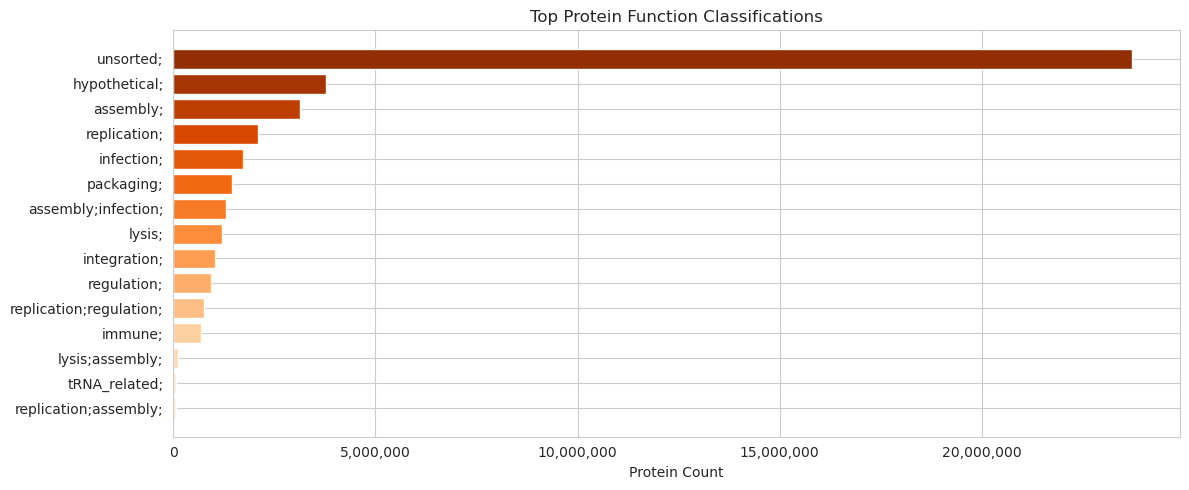

In [28]:
if "dim_proteins" in table_names:
    protein_classes = conn.execute("""
        SELECT
            COALESCE(Protein_classification, 'Unknown') AS classification,
            COUNT(*) AS protein_count
        FROM dim_proteins
        GROUP BY Protein_classification
        ORDER BY protein_count DESC
        LIMIT 15
    """).fetchdf()
    print("Top protein classifications:")
    display(protein_classes)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(protein_classes["classification"][::-1],
            protein_classes["protein_count"][::-1],
            color=sns.color_palette("Oranges", len(protein_classes)))
    ax.set_xlabel("Protein Count")
    ax.set_title("Top Protein Function Classifications")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.show()
else:
    print("dim_proteins table not found.")

## 8. Close Database Connection

In [29]:
conn.close()
print("Database connection closed.")

Database connection closed.


## Summary

This notebook demonstrated:

- ✅ **Database connectivity** — DuckDB opens in read-only mode without requiring a full PBI installation
- ✅ **Schema overview** — all tables (fact + dimensions) are listed with row counts
- ✅ **Phage metadata** — source distribution, genome length, GC content, lifestyle, completeness, top hosts
- ✅ **Annotation coverage** — which fraction of phages have proteins, terminators, AMR genes, etc.
- ✅ **Host files** — CSV and JSON files in `hosts/` with species and assembly metadata
- ✅ **Data-merging reports** — links to HTML reports documenting the ETL pipeline
- ✅ **Example queries** — cross-table JOINs to find phages by host, lifestyle, or annotation

## Further Resources

| Resource | URL |
|---|---|
| PBI GitHub repository | https://github.com/ThibaultSchowing/PBI |
| PBI documentation | https://thibaultschowing.github.io/PBI/ |
| DuckDB documentation | https://duckdb.org/docs/ |

## Analysis output layout (durable exports)
Generated artifacts are written to `NOTEBOOK_RESULTS_DIR`, rooted at `/results` in Docker (mounted from `./analysis_results`):
- `tables/` for exported DataFrames (`.parquet`)
- `figures/` for saved plots (`.png`)
This keeps source notebooks in `/workspace` clean while preserving reproducible outputs in `/results`.
Note: all currently open matplotlib figures are exported to `figures/` when running the export cell.


In [ ]:
# Export meaningful notebook artifacts to durable results storage
import pandas as pd

candidate_tables = {
    'manifest': globals().get('manifest'),
    'tables': globals().get('tables'),
    'phage_meta': globals().get('phage_meta'),
    'host_meta': globals().get('host_meta'),
    'counts_df': globals().get('counts_df'),
    'coverage_df': globals().get('coverage_df'),
    'assembly_meta': globals().get('assembly_meta'),
    'links_df': globals().get('links_df'),
    'proteins_df': globals().get('proteins_df'),
    'phage_files_df': globals().get('phage_files_df'),
    'df': globals().get('df'),
}

exported_tables = []
for name, value in candidate_tables.items():
    if isinstance(value, pd.DataFrame) and not value.empty:
        output_path = TABLES_DIR / f"{name}.parquet"
        value.to_parquet(output_path, index=False)
        exported_tables.append(output_path)

exported_figures = []
for fig_num in plt.get_fignums():
    fig_path = FIGURES_DIR / f"figure_{fig_num}.png"
    plt.figure(fig_num).savefig(fig_path, dpi=300, bbox_inches='tight')
    exported_figures.append(fig_path)

print(f"Exported {len(exported_tables)} table(s) to: {TABLES_DIR}")
for p in exported_tables:
    print(f" - {p.name}")

print(f"Exported {len(exported_figures)} figure(s) to: {FIGURES_DIR}")
for p in exported_figures:
    print(f" - {p.name}")

